# AccessFlow Toronto — Road Restrictions Analysis

Analysis of **real Toronto Open Data road-restriction feeds** (1,834 closures).
Data source: City of Toronto road-restrictions XML feed.

This notebook parses the raw XML, extracts meaningful fields, and visualizes
restriction patterns, temporal distributions, and spatial coverage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)

FIXTURES = Path('../fixtures')
XML_FILE = FIXTURES / 'road-restrictions--resource-3afea38a-baad-4f39-b22f-d608875e1746.xml'
print('Setup complete.')

Setup complete.


## 1. Parse Raw XML Data

The Toronto road-restrictions feed is an XML file with `<Closure>` elements.
Each closure represents a road restriction (construction, road closure, etc.).

In [2]:
import xml.etree.ElementTree as ET

tree = ET.parse(XML_FILE)
root = tree.getroot()

# Parse all closures
records = []
for closure in root.findall('.//Closure'):
    record = {}
    for field in closure:
        record[field.tag] = field.text
    records.append(record)

df = pd.DataFrame(records)
print(f'Parsed {len(df)} closures from XML')
print(f'Fields: {list(df.columns)}')

Parsed 1834 closures from XML
Fields: ['Id', 'Road', 'Name', 'District', 'Latitude', 'Longitude', 'RoadClass', 'Planned', 'SeverityOverride', 'Source', 'CreatedTime', 'LastUpdated', 'StartTime', 'EndTime', 'WorkPeriod', 'Expired', 'Signing', 'Notification', 'WorkEventType', 'Contractor', 'PermitType', 'Description', 'SpecialEvent', 'FromRoad', 'ToRoad', 'AtRoad', 'DirectionsAffected', 'Type', 'SubType', 'ScheduleMonday', 'ScheduleTuesday', 'ScheduleWednesday', 'ScheduleThursday', 'ScheduleFriday', 'ScheduleSaturday', 'ScheduleSunday', 'ScheduleEveryday', 'URL', 'GeoPolyline', 'MaxImpact', 'CurrImpact']


## 2. Data Overview

First look at the raw data: what fields are available, what are the values?

In [3]:
print('Shape:', df.shape)
print()
print('First 3 rows:')
print(df.head(3).to_string())
print()
print('Data types:')
print(df.dtypes)

Shape: (1834, 41)

First 3 rows:
                   Id                  Road                                                       Name District   Latitude   Longitude            RoadClass Planned SeverityOverride Source    CreatedTime    LastUpdated      StartTime        EndTime WorkPeriod Expired Signing Notification WorkEventType                          Contractor PermitType                                                                                                        Description SpecialEvent              FromRoad        ToRoad AtRoad DirectionsAffected          Type                   SubType ScheduleMonday ScheduleTuesday ScheduleWednesday ScheduleThursday ScheduleFriday ScheduleSaturday ScheduleSunday ScheduleEveryday                                                                                                                   URL                                    GeoPolyline MaxImpact CurrImpact
0  Tor-RD1S2026-338-2             King St W        King St W from Ln E S

## 3. Clean and Convert Fields

Convert timestamps from epoch milliseconds to readable dates.
Parse numeric fields. Extract lat/lon from GeoPolyline.

In [4]:
# Convert epoch milliseconds to datetime
for col in ['StartTime', 'EndTime', 'CreatedTime', 'LastUpdated']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col + '_dt'] = pd.to_datetime(df[col], unit='ms', errors='coerce')

# Convert numeric fields
for col in ['Latitude', 'Longitude', 'Planned', 'SeverityOverride', 'Expired']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Calculate duration in days
if 'StartTime_dt' in df.columns and 'EndTime_dt' in df.columns:
    df['Duration_days'] = (df['EndTime_dt'] - df['StartTime_dt']).dt.total_seconds() / 86400

print('Converted fields.')
print(f'Start time range: {df["StartTime_dt"].min()} to {df["StartTime_dt"].max()}')
print(f'End time range: {df["EndTime_dt"].min()} to {df["EndTime_dt"].max()}')

Converted fields.
Start time range: 2024-02-28 05:01:00 to 2027-01-01 05:00:00
End time range: 2026-09-07 19:00:00 to 2029-12-31 05:00:00


## 4. Restriction Types

What types of restrictions exist? How are they distributed?

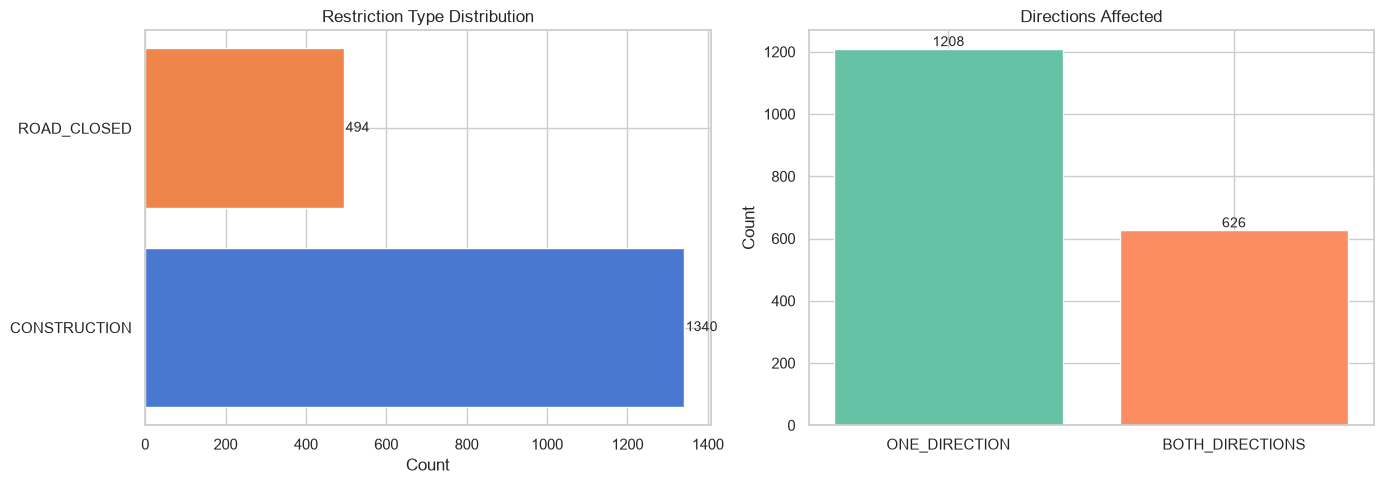

Saved: fixtures/restriction_types.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Type distribution
type_counts = df['Type'].value_counts()
axes[0].barh(type_counts.index, type_counts.values, color=sns.color_palette('muted', len(type_counts)))
axes[0].set_xlabel('Count')
axes[0].set_title('Restriction Type Distribution')
for i, v in enumerate(type_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=10)

# Directions affected
dir_counts = df['DirectionsAffected'].value_counts()
axes[1].bar(dir_counts.index, dir_counts.values, color=sns.color_palette('Set2', len(dir_counts)))
axes[1].set_ylabel('Count')
axes[1].set_title('Directions Affected')
for i, v in enumerate(dir_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../fixtures/restriction_types.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fixtures/restriction_types.png')

## 5. Work Period Schedules

When do these restrictions operate? Daily, weekdays, weekends, or continuously?

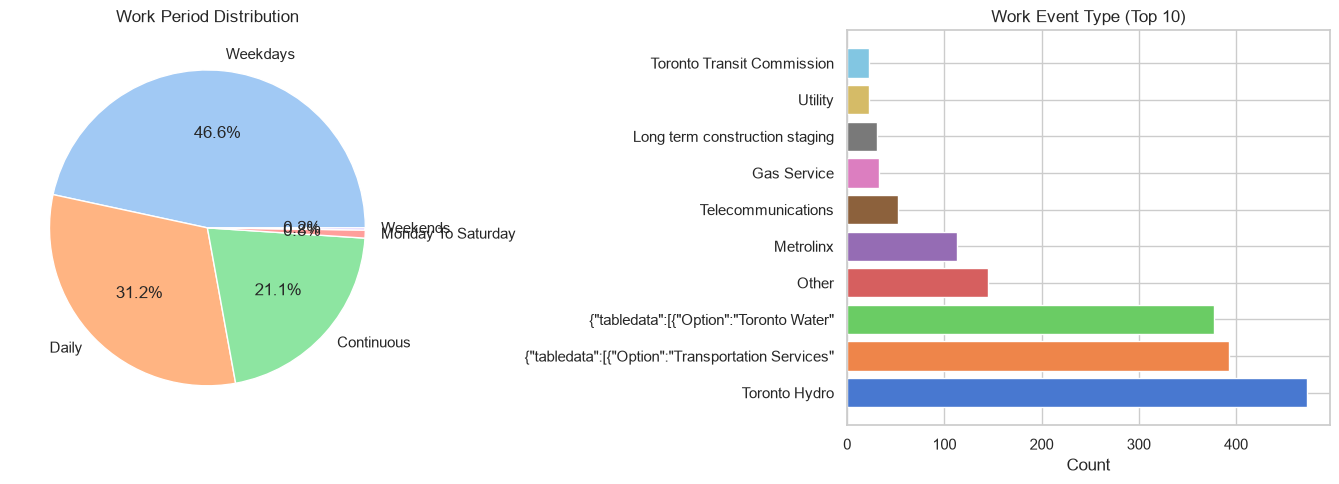

Saved: fixtures/work_periods.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Work period distribution
wp_counts = df['WorkPeriod'].value_counts()
colors = sns.color_palette('pastel', len(wp_counts))
axes[0].pie(wp_counts.values, labels=wp_counts.index, autopct='%1.1f%%', colors=colors)
axes[0].set_title('Work Period Distribution')

# Work event types
we_counts = df['WorkEventType'].value_counts().head(10)
axes[1].barh(we_counts.index, we_counts.values, color=sns.color_palette('muted', len(we_counts)))
axes[1].set_xlabel('Count')
axes[1].set_title('Work Event Type (Top 10)')

plt.tight_layout()
plt.savefig('../fixtures/work_periods.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fixtures/work_periods.png')

## 6. Temporal Patterns

When do restrictions start? Are there seasonal or monthly patterns?

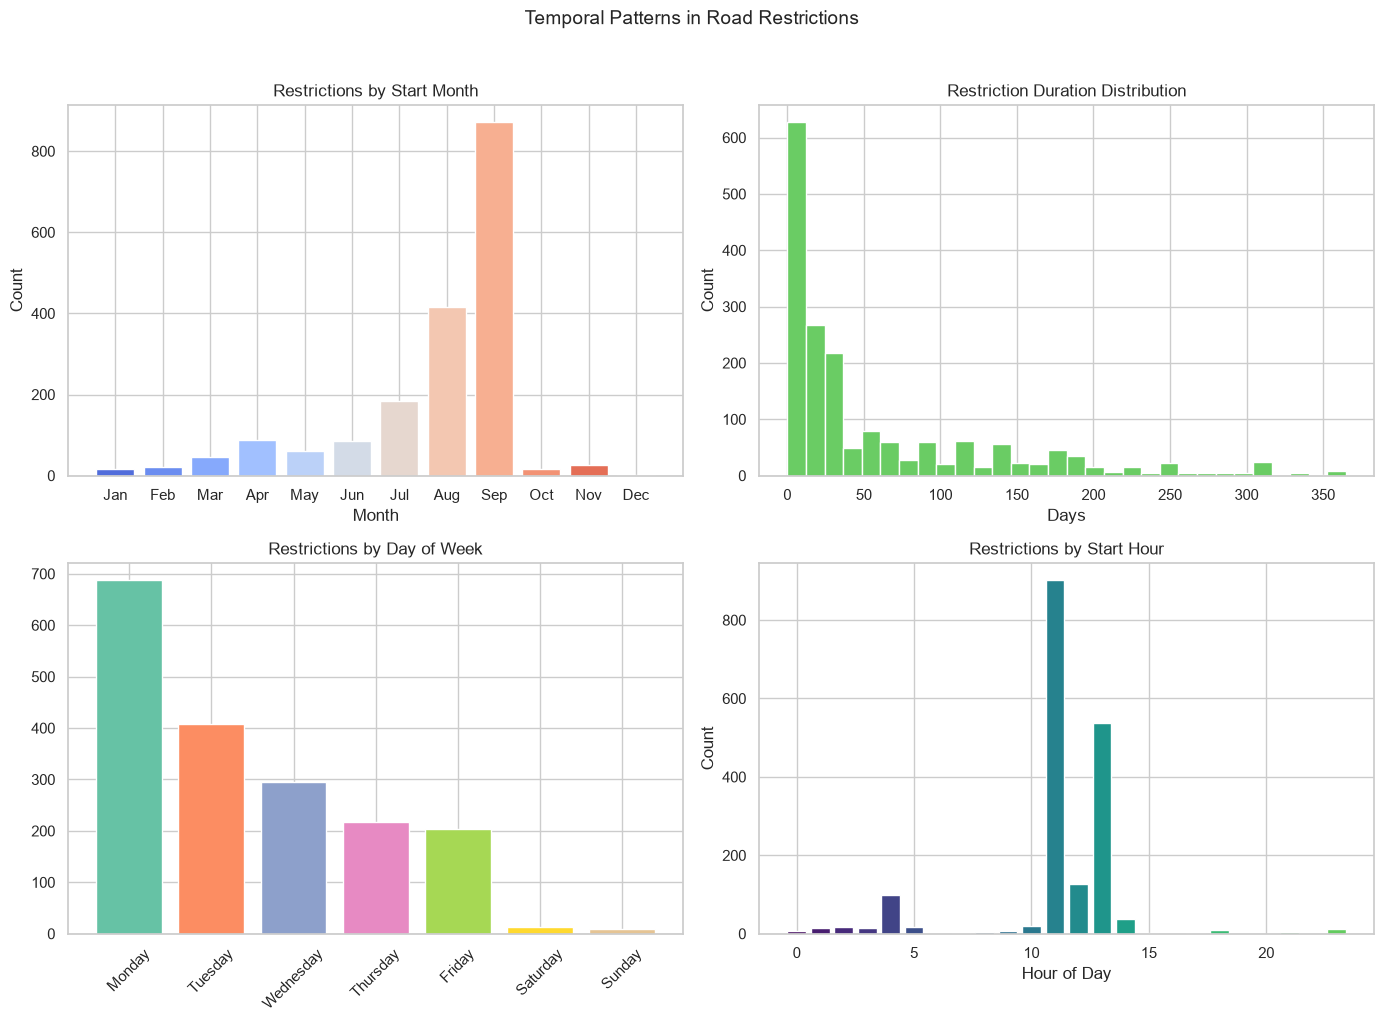

Saved: fixtures/temporal_patterns.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Start time by month
if 'StartTime_dt' in df.columns:
    df['StartMonth'] = df['StartTime_dt'].dt.month
    month_counts = df['StartMonth'].value_counts().sort_index()
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    labels = [month_names[int(m)-1] for m in month_counts.index if 1 <= int(m) <= 12]
    vals = [month_counts[int(m)] for m in month_counts.index if 1 <= int(m) <= 12]
    axes[0, 0].bar(labels, vals, color=sns.color_palette('coolwarm', len(labels)))
    axes[0, 0].set_title('Restrictions by Start Month')
    axes[0, 0].set_xlabel('Month')
    axes[0, 0].set_ylabel('Count')

# Duration distribution
if 'Duration_days' in df.columns:
    dur = df['Duration_days'].dropna()
    dur = dur[dur > 0]
    dur = dur[dur < 365]
    axes[0, 1].hist(dur, bins=30, color=sns.color_palette('muted')[2], edgecolor='white')
    axes[0, 1].set_title('Restriction Duration Distribution')
    axes[0, 1].set_xlabel('Days')
    axes[0, 1].set_ylabel('Count')

# Day of week distribution
if 'StartTime_dt' in df.columns:
    df['StartDay'] = df['StartTime_dt'].dt.day_name()
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_counts = df['StartDay'].value_counts().reindex(day_order).dropna()
    axes[1, 0].bar(day_counts.index, day_counts.values, color=sns.color_palette('Set2', 7))
    axes[1, 0].set_title('Restrictions by Day of Week')
    axes[1, 0].tick_params(axis='x', rotation=45)

# Hour of day distribution
if 'StartTime_dt' in df.columns:
    df['StartHour'] = df['StartTime_dt'].dt.hour
    hour_counts = df['StartHour'].value_counts().sort_index()
    axes[1, 1].bar(hour_counts.index, hour_counts.values, color=sns.color_palette('viridis', 24))
    axes[1, 1].set_title('Restrictions by Start Hour')
    axes[1, 1].set_xlabel('Hour of Day')
    axes[1, 1].set_ylabel('Count')

plt.suptitle('Temporal Patterns in Road Restrictions', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('../fixtures/temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fixtures/temporal_patterns.png')

## 7. Road Classes and Severity

What types of roads are affected? How severe are the restrictions?

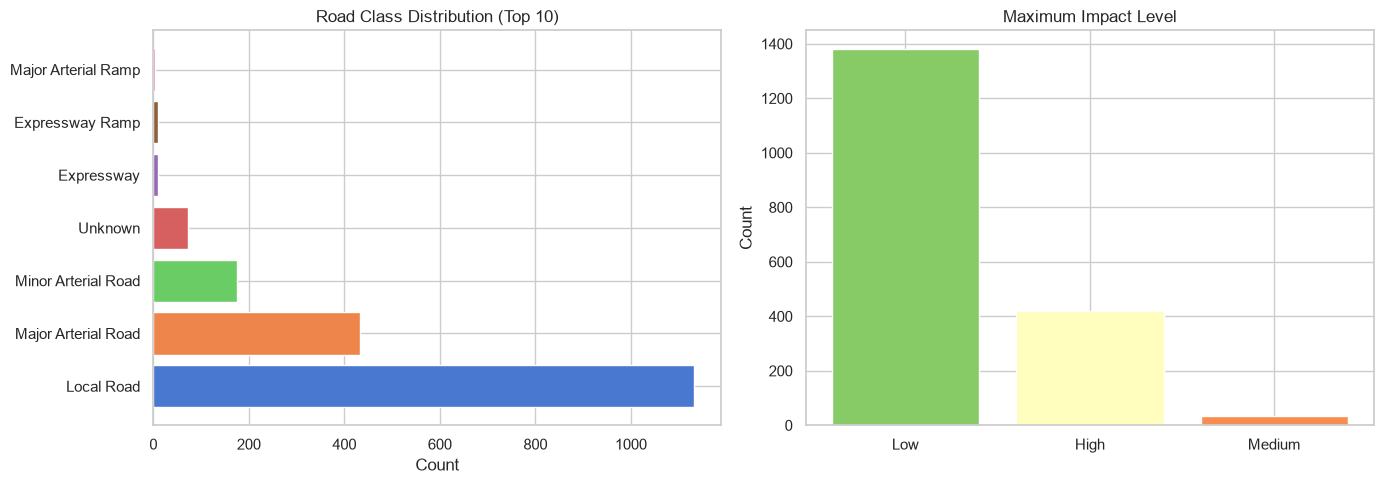

Saved: fixtures/road_classes.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Road class distribution
rc_counts = df['RoadClass'].value_counts().head(10)
axes[0].barh(rc_counts.index, rc_counts.values, color=sns.color_palette('muted', len(rc_counts)))
axes[0].set_xlabel('Count')
axes[0].set_title('Road Class Distribution (Top 10)')

# Max impact distribution
if 'MaxImpact' in df.columns:
    mi_counts = df['MaxImpact'].value_counts()
    axes[1].bar(mi_counts.index, mi_counts.values, color=sns.color_palette('RdYlGn_r', len(mi_counts)))
    axes[1].set_ylabel('Count')
    axes[1].set_title('Maximum Impact Level')

plt.tight_layout()
plt.savefig('../fixtures/road_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fixtures/road_classes.png')

## 8. Geographic Distribution

Where are the restrictions located? Scatter plot of lat/lon.

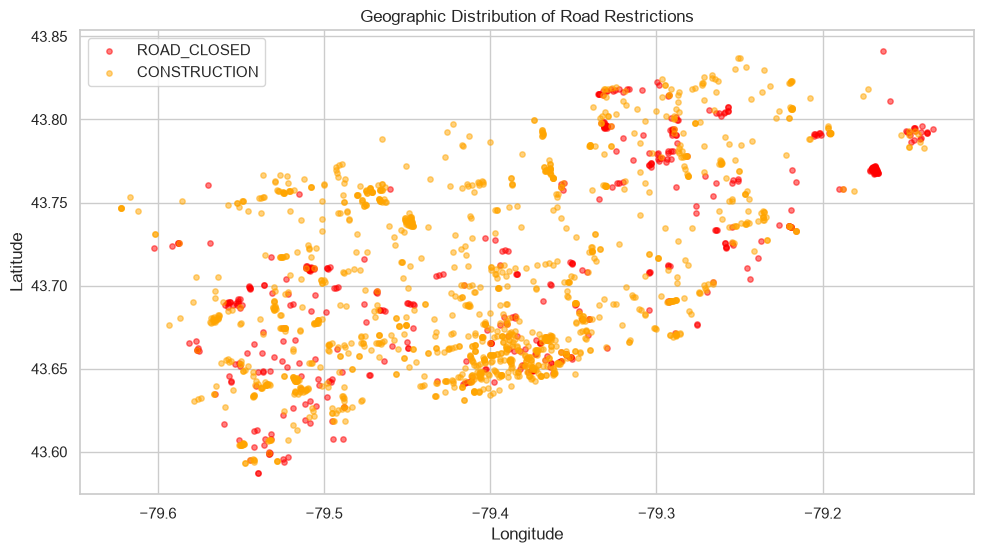

Saved: fixtures/geographic_scatter.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 10))

# Color by type
type_colors = {'ROAD_CLOSED': 'red', 'CONSTRUCTION': 'orange', 'OTHER': 'gray'}
for t, color in type_colors.items():
    mask = df['Type'] == t
    if mask.sum() > 0:
        ax.scatter(df.loc[mask, 'Longitude'], df.loc[mask, 'Latitude'],
                  c=color, label=t, alpha=0.5, s=15)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geographic Distribution of Road Restrictions')
ax.legend()
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('../fixtures/geographic_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fixtures/geographic_scatter.png')

## 9. Contractor Analysis

Who is responsible for these restrictions? Top contractors by volume.

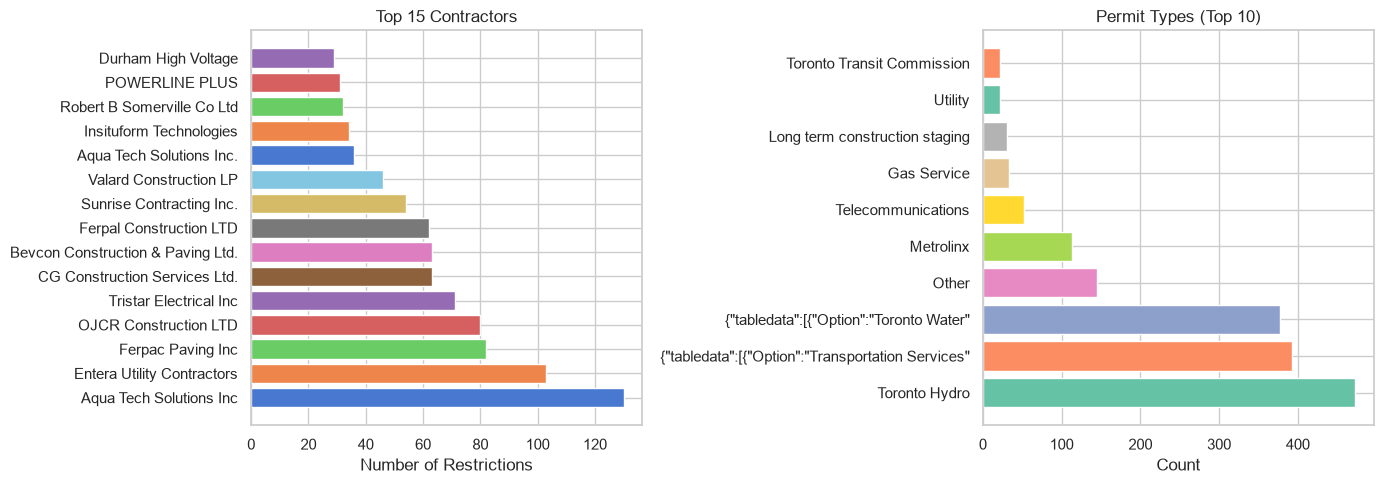

Saved: fixtures/contractors.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top contractors
if 'Contractor' in df.columns:
    contractor_counts = df['Contractor'].value_counts().head(15)
    axes[0].barh(contractor_counts.index, contractor_counts.values, color=sns.color_palette('muted', len(contractor_counts)))
    axes[0].set_xlabel('Number of Restrictions')
    axes[0].set_title('Top 15 Contractors')

# Permit types
if 'PermitType' in df.columns:
    permit_counts = df['PermitType'].value_counts().head(10)
    axes[1].barh(permit_counts.index, permit_counts.values, color=sns.color_palette('Set2', len(permit_counts)))
    axes[1].set_xlabel('Count')
    axes[1].set_title('Permit Types (Top 10)')

plt.tight_layout()
plt.savefig('../fixtures/contractors.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fixtures/contractors.png')

## 10. Summary Statistics

Key numbers from the Toronto road-restrictions feed.

## 11. Machine Learning Gate

**ADR-003** defines the prediction target (CurrImpact), label source, leakage controls,
and validation strategy. See docs/adr/ADR-003-ml-prediction-target.md for details.

**Current status:** Conditions 1–4 met. Conditions 5–7 not yet met.

| # | Condition | Status |
|---|---|---|
| 1 | Prediction target documented | This ADR |
| 2 | Label source identified | CurrImpact (applicant-submitted) |
| 3 | Leakage controls documented | Excluded features listed |
| 4 | Validation strategy defined | Temporal + geographic splits |
| 5 | Baseline model achieved | **Not yet** |
| 6 | Model exceeds baseline | **Not yet** |
| 7 | External validation | **Not yet** |

**Next step:** Train baseline logistic regression on CurrImpact (merge Medium into Low)
using temporal split. Evaluate F1-score against always-predict-None baseline.

In [11]:
print('=' * 60)
print('TORONTO ROAD RESTRICTIONS — SUMMARY')
print('=' * 60)
print(f'Total closures: {len(df)}')
print(f'Type breakdown:')
for t, c in df['Type'].value_counts().items():
    print(f'  {t}: {c}')
print()
print(f'Directions:')
for d, c in df['DirectionsAffected'].value_counts().items():
    print(f'  {d}: {c}')
print()
print(f'Work periods:')
for w, c in df['WorkPeriod'].value_counts().items():
    print(f'  {w}: {c}')
print()
if 'Duration_days' in df.columns:
    dur = df['Duration_days'].dropna()
    dur = dur[dur > 0]
    print(f'Duration stats (days):')
    print(f'  Mean: {dur.mean():.1f}')
    print(f'  Median: {dur.median():.1f}')
    print(f'  Min: {dur.min():.1f}')
    print(f'  Max: {dur.max():.1f}')
print()
print(f'Latitude range: {df["Latitude"].min():.4f} to {df["Latitude"].max():.4f}')
print(f'Longitude range: {df["Longitude"].min():.4f} to {df["Longitude"].max():.4f}')
print()
print(f'Top 5 roads:')
for road, c in df['Road'].value_counts().head(5).items():
    print(f'  {road}: {c}')

TORONTO ROAD RESTRICTIONS — SUMMARY
Total closures: 1834
Type breakdown:
  CONSTRUCTION: 1340
  ROAD_CLOSED: 494

Directions:
  ONE_DIRECTION: 1208
  BOTH_DIRECTIONS: 626

Work periods:
  Weekdays: 855
  Daily: 573
  Continuous: 387
  Monday To Saturday: 15
  Weekends: 4

Duration stats (days):
  Mean: 76.3
  Median: 24.5
  Min: 0.0
  Max: 1739.7

Latitude range: 43.5871 to 43.8409
Longitude range: -79.6222 to -79.1333

Top 5 roads:
  Leslie St: 30
  Eglinton Ave E: 25
  Dundas St W: 23
  Bloor St W: 22
  Morning Dew Rd: 18
